# Sprint Semana 6 — Combinación Tardía LSP
**BiLSTM + ST-GCN sobre landmarks MediaPipe → combinación tardía**

Checkpoints disponibles:
- `checkpoints/lstm_best.pt` — LSTMBidir (F1-val=0.734)
- `checkpoints/stgcn_best.pt` — STGCN ligero (F1-val=0.496)

In [25]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

device = ('mps'  if torch.backends.mps.is_available() else
          'cuda' if torch.cuda.is_available()          else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print(f'ROOT={ROOT}  device={device}  torch={torch.__version__}')

ROOT=/Users/usuario/Documents/TRADUCTOR_LSP  device=mps  torch=2.2.2


## 1. Datos

In [26]:
DATA_DIR = ROOT / 'data'
with open(DATA_DIR / 'label2idx.json') as f:
    label2idx = json.load(f)
idx2label   = {v: k for k, v in label2idx.items()}
N_CLASSES   = len(label2idx)
CLASS_NAMES = [idx2label[i] for i in range(N_CLASSES)]

df = pd.read_csv(DATA_DIR / 'manifest_segments.csv')
df = df[df['kp_path'].notna() & (df['kp_path'] != '')].reset_index(drop=True)
df_tr = df[df['split'] == 'train']
df_vl = df[df['split'] == 'val']
df_te = df[df['split'] == 'test']
print(f'{N_CLASSES} clases | train={len(df_tr)} val={len(df_vl)} test={len(df_te)}')

26 clases | train=5051 val=1085 test=1099


In [27]:
T_FRAMES = 30
N_KP     = 75

class LandmarkDS(Dataset):
    def __init__(self, df, l2i, augment=False):
        self.df = df.reset_index(drop=True)
        self.l2i = l2i
        self.aug = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        seq = np.load(str(ROOT / row['kp_path'])).astype(np.float32)  # ruta absoluta
        T = len(seq)
        if T > T_FRAMES:
            seq = seq[:T_FRAMES]
        elif T < T_FRAMES:
            seq = np.concatenate([seq, np.zeros((T_FRAMES-T, N_KP, 3), np.float32)])
        if self.aug:
            if np.random.rand() < 0.6:
                seq += np.random.normal(0, 0.012, seq.shape).astype(np.float32)
            if np.random.rand() < 0.5:
                seq = seq.copy(); seq[:,:,0] *= -1
                l, r = seq[:,:21].copy(), seq[:,21:42].copy()
                seq[:,:21], seq[:,21:42] = r, l
        return torch.from_numpy(seq), self.l2i[row['clase']]

def make_loader(df_s, augment=False, batch=64):
    ds  = LandmarkDS(df_s, label2idx, augment=augment)
    smp = None
    if augment:
        cnt = df_s['clase'].value_counts()
        wts = [1.0/cnt[r['clase']] for _, r in df_s.iterrows()]
        smp = WeightedRandomSampler(wts, len(wts), replacement=True)
    return DataLoader(ds, batch_size=batch, sampler=smp,
                      shuffle=(not augment), num_workers=0, pin_memory=False)

tr_dl = make_loader(df_tr, augment=True)
vl_dl = make_loader(df_vl)
te_dl = make_loader(df_te)
print('DataLoaders OK')

DataLoaders OK


## 2. Modelos backbone (arquitecturas exactas de run_local_pipeline.py)

In [28]:
class LSTMBidir(nn.Module):
    """Arquitectura exacta que generó checkpoints/lstm_best.pt"""
    def __init__(self, n_kp=75, n_coords=3, n_clases=26, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(n_kp * n_coords, 128)
        self.lstm = nn.LSTM(128, hidden, n_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if n_layers > 1 else 0.0)
        self.attn = nn.Linear(hidden * 2, 1)
        self.fc   = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden * 2, n_clases))
        self.emb_dim = hidden * 2

    def get_embedding(self, x):          # x: [B, T, KP, 3]
        B, T, KP, C = x.shape
        x = F.gelu(self.proj(x.view(B, T, KP * C)))
        h, _ = self.lstm(x)
        w = torch.softmax(self.attn(h), dim=1)
        return (w * h).sum(1)            # [B, hidden*2]

    def forward(self, x):
        return self.fc(self.get_embedding(x))


class SimpleSTGCN(nn.Module):
    """Arquitectura exacta que generó checkpoints/stgcn_best.pt"""
    def __init__(self, n_kp=75, n_coords=3, n_clases=26, hidden=128, dropout=0.3):
        super().__init__()
        self.embed = nn.Linear(n_coords, 32)
        self.A     = nn.Parameter(torch.eye(n_kp))
        self.gcn1  = nn.Linear(32, hidden)
        self.gcn2  = nn.Linear(hidden, hidden)
        self.tcn   = nn.Sequential(nn.Conv1d(hidden, hidden, 3, padding=1), nn.GELU())
        self.fc    = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, n_clases))
        self.emb_dim = hidden

    def get_embedding(self, x):          # x: [B, T, KP, C]
        B, T, KP, C = x.shape
        x = F.gelu(self.embed(x))        # [B, T, KP, 32]
        A = F.softmax(self.A, dim=-1)
        xr = x.reshape(B * T, KP, 32)
        xr = F.gelu(self.gcn1(torch.bmm(A.unsqueeze(0).expand(B*T,-1,-1), xr)))
        xr = F.gelu(self.gcn2(torch.bmm(A.unsqueeze(0).expand(B*T,-1,-1), xr)))
        xr = xr.mean(1).reshape(B, T, -1).permute(0, 2, 1)  # [B, hidden, T]
        return self.tcn(xr).mean(-1)     # [B, hidden]

    def forward(self, x):
        return self.fc(self.get_embedding(x))


print('Clases definidas OK')

Clases definidas OK


## 3. Cargar checkpoints y evaluar backbones individuales

In [29]:
@torch.no_grad()
def evaluate(model, loader, label=''):
    model.eval()
    preds, trues = [], []
    for seq, y in loader:
        seq, y = seq.to(device), y.to(device)
        preds.extend(model(seq).argmax(1).cpu().numpy())
        trues.extend(y.cpu().numpy())
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)
    f1w = f1_score(trues, preds, average='weighted', zero_division=0)
    if label:
        print(f'{label:30s}  acc={acc:.4f}  F1-macro={f1:.4f}  F1-weighted={f1w:.4f}')
    return acc, f1, f1w, np.array(trues), np.array(preds)


CKPT = ROOT / 'checkpoints'

# Cargar BiLSTM
m_lstm = LSTMBidir().to(device)
ck = torch.load(CKPT / 'lstm_best.pt', map_location='cpu', weights_only=False)
m_lstm.load_state_dict(ck['state_dict'])
print(f'BiLSTM cargado  — val F1={float(ck["f1_val"]):.4f}')

# Cargar ST-GCN
m_stgcn = SimpleSTGCN().to(device)
ck2 = torch.load(CKPT / 'stgcn_best.pt', map_location='cpu', weights_only=False)
m_stgcn.load_state_dict(ck2['state_dict'])
print(f'ST-GCN cargado  — val F1={float(ck2["f1_val"]):.4f}')

# Congelar backbones
for p in m_lstm.parameters():  p.requires_grad_(False)
for p in m_stgcn.parameters(): p.requires_grad_(False)

# Evaluar individualmente en test set
print('\nEvaluación TEST set:')
acc_l, f1_l, f1w_l, yt_l, yp_l = evaluate(m_lstm,  te_dl, 'BiLSTM (backbone A)')
acc_s, f1_s, f1w_s, yt_s, yp_s = evaluate(m_stgcn, te_dl, 'ST-GCN (backbone B)')

# Guardar resultados
results = {
    'BiLSTM (baseline)': {'acc': acc_l, 'f1': f1_l, 'f1w': f1w_l,
                          'y_true': yt_l, 'y_pred': yp_l},
    'ST-GCN (baseline)': {'acc': acc_s, 'f1': f1_s, 'f1w': f1w_s,
                          'y_true': yt_s, 'y_pred': yp_s},
}

BiLSTM cargado  — val F1=0.7340
ST-GCN cargado  — val F1=0.4962

Evaluación TEST set:
BiLSTM (backbone A)             acc=0.2684  F1-macro=0.1515  F1-weighted=0.2385
ST-GCN (backbone B)             acc=0.3085  F1-macro=0.2077  F1-weighted=0.2833


## 4. Módulo de combinación tardía

In [30]:
DIM_A = m_lstm.emb_dim    # 256
DIM_B = m_stgcn.emb_dim  # 128
print(f'Embedding dims: BiLSTM={DIM_A}  ST-GCN={DIM_B}')


class CabezaCombinada(nn.Module):
    def __init__(self, dim_a, dim_b, n_classes, strategy='concat',
                 hidden=256, dropout=0.35):
        super().__init__()
        self.strategy = strategy

        if strategy == 'concat':
            self.net = nn.Sequential(
                nn.Linear(dim_a + dim_b, hidden), nn.LayerNorm(hidden),
                nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, n_classes))

        elif strategy == 'attention':
            self.pa  = nn.Linear(dim_a, hidden)
            self.pb  = nn.Linear(dim_b, hidden)
            self.att = nn.MultiheadAttention(hidden, num_heads=4,
                                             batch_first=True, dropout=dropout)
            self.net = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(dropout),
                                     nn.Linear(hidden, n_classes))

        elif strategy == 'weighted_sum':
            self.pa   = nn.Linear(dim_a, hidden)
            self.pb   = nn.Linear(dim_b, hidden)
            self.gate = nn.Parameter(torch.tensor(0.5))
            self.net  = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(dropout),
                                      nn.Linear(hidden, n_classes))

    def forward(self, ea, eb):
        if self.strategy == 'concat':
            return self.net(torch.cat([ea, eb], dim=-1))
        elif self.strategy == 'attention':
            q, k = self.pa(ea).unsqueeze(1), self.pb(eb).unsqueeze(1)
            out, _ = self.att(q, k, k)
            return self.net(out.squeeze(1))
        elif self.strategy == 'weighted_sum':
            alpha = torch.sigmoid(self.gate)
            return self.net(alpha * self.pa(ea) + (1-alpha) * self.pb(eb))


class ModeloCombinado(nn.Module):
    def __init__(self, bb_a, bb_b, strategy, hidden=256, dropout=0.35):
        super().__init__()
        self.bb_a = bb_a  # congelado
        self.bb_b = bb_b  # congelado
        self.head = CabezaCombinada(bb_a.emb_dim, bb_b.emb_dim,
                               N_CLASSES, strategy, hidden, dropout)

    def forward(self, x):
        with torch.no_grad():
            ea = self.bb_a.get_embedding(x)
            eb = self.bb_b.get_embedding(x)
        return self.head(ea, eb)


print('CabezaCombinada definido')

Embedding dims: BiLSTM=256  ST-GCN=128
CabezaCombinada definido


## 5. Entrenamiento de variantes de fusión

In [31]:
def run_variante(strategy, epochs=25, lr=5e-4, patience=8):
    model = ModeloCombinado(m_lstm, m_stgcn, strategy).to(device)
    opt   = torch.optim.AdamW(model.head.parameters(), lr=lr, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_f1, best_state, no_imp = 0.0, None, 0
    hist = {'tr_f1': [], 'vl_f1': [], 'vl_acc': []}
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train()
        p_all, t_all = [], []
        for seq, y in tr_dl:
            seq, y = seq.to(device), y.to(device)
            opt.zero_grad()
            out = model(seq)
            crit(out, y).backward()
            torch.nn.utils.clip_grad_norm_(model.head.parameters(), 1.0)
            opt.step()
            p_all.extend(out.detach().argmax(1).cpu().numpy())
            t_all.extend(y.cpu().numpy())
        sch.step()
        tr_f1 = f1_score(t_all, p_all, average='macro', zero_division=0)

        model.eval()
        with torch.no_grad():
            vp, vt = [], []
            for seq, y in vl_dl:
                vp.extend(model(seq.to(device)).argmax(1).cpu().numpy())
                vt.extend(y.numpy())
        vl_acc = accuracy_score(vt, vp)
        vl_f1  = f1_score(vt, vp, average='macro', zero_division=0)
        hist['tr_f1'].append(tr_f1)
        hist['vl_f1'].append(vl_f1)
        hist['vl_acc'].append(vl_acc)

        mark = ''
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            best_state = {k: v.cpu().clone() for k, v in model.head.state_dict().items()}
            no_imp = 0; mark = ' ✓'
        else:
            no_imp += 1
        print(f'  ep {ep:2d}/{epochs} | tr_f1={tr_f1:.3f} vl_f1={vl_f1:.3f} vl_acc={vl_acc:.3f}{mark}')
        if no_imp >= patience:
            print(f'  Early stop ep={ep}'); break

    model.head.load_state_dict(best_state)
    acc_te, f1_te, f1w_te, y_true, y_pred = evaluate(model, te_dl)
    print(f'\n  TEST acc={acc_te:.4f}  F1-macro={f1_te:.4f}  F1-weighted={f1w_te:.4f}')
    print(f'  Tiempo: {(time.time()-t0)/60:.1f} min')
    return {'acc': acc_te, 'f1': f1_te, 'f1w': f1w_te,
            'y_true': y_true, 'y_pred': y_pred, 'hist': hist,
            'model': model, 'best_val_f1': best_f1}


print('='*60)
print('Variante A — Fusión CONCAT  (BiLSTM 256-dim + ST-GCN 128-dim)')
print('='*60)
results['Combinación concat'] = run_variante('concat', epochs=25, lr=5e-4)

print('\n' + '='*60)
print('Variante B — Fusión ATTENTION  (cross-attn 4 heads)')
print('='*60)
results['Combinación attention'] = run_variante('attention', epochs=25, lr=3e-4)

Variante A — Fusión CONCAT  (BiLSTM 256-dim + ST-GCN 128-dim)
  ep  1/25 | tr_f1=0.313 vl_f1=0.355 vl_acc=0.476 ✓
  ep  2/25 | tr_f1=0.501 vl_f1=0.472 vl_acc=0.571 ✓
  ep  3/25 | tr_f1=0.582 vl_f1=0.464 vl_acc=0.577
  ep  4/25 | tr_f1=0.605 vl_f1=0.516 vl_acc=0.624 ✓
  ep  5/25 | tr_f1=0.640 vl_f1=0.540 vl_acc=0.623 ✓
  ep  6/25 | tr_f1=0.649 vl_f1=0.545 vl_acc=0.643 ✓
  ep  7/25 | tr_f1=0.676 vl_f1=0.555 vl_acc=0.632 ✓
  ep  8/25 | tr_f1=0.693 vl_f1=0.588 vl_acc=0.665 ✓
  ep  9/25 | tr_f1=0.691 vl_f1=0.558 vl_acc=0.654
  ep 10/25 | tr_f1=0.710 vl_f1=0.577 vl_acc=0.665
  ep 11/25 | tr_f1=0.707 vl_f1=0.581 vl_acc=0.663
  ep 12/25 | tr_f1=0.721 vl_f1=0.564 vl_acc=0.645
  ep 13/25 | tr_f1=0.732 vl_f1=0.569 vl_acc=0.655
  ep 14/25 | tr_f1=0.742 vl_f1=0.574 vl_acc=0.660
  ep 15/25 | tr_f1=0.750 vl_f1=0.593 vl_acc=0.678 ✓
  ep 16/25 | tr_f1=0.753 vl_f1=0.600 vl_acc=0.678 ✓
  ep 17/25 | tr_f1=0.756 vl_f1=0.599 vl_acc=0.683
  ep 18/25 | tr_f1=0.763 vl_f1=0.603 vl_acc=0.677 ✓
  ep 19/25 | tr_f1

## 6. Tabla comparativa final

In [32]:
rows = []
for name, r in results.items():
    rows.append({'Modelo': name,
                 'F1-macro': round(r['f1'], 4),
                 'F1-weighted': round(r['f1w'], 4),
                 'Accuracy': round(r['acc'], 4)})
tabla = pd.DataFrame(rows).set_index('Modelo').sort_values('F1-macro', ascending=False)
print('\n=== TABLA COMPARATIVA SPRINT SEMANA 6 ===')
print(tabla.to_string())

# Guardar CSV
tabla.to_csv(DATA_DIR / 'semana6_resultados.csv')
print('\nGuardado: data/semana6_resultados.csv')


=== TABLA COMPARATIVA SPRINT SEMANA 6 ===
                       F1-macro  F1-weighted  Accuracy
Modelo                                                
Combinación concat       0.5056       0.5932    0.5905
Combinación attention    0.3197       0.3740    0.3767
ST-GCN (baseline)        0.2077       0.2833    0.3085
BiLSTM (baseline)        0.1515       0.2385    0.2684

Guardado: data/semana6_resultados.csv


## 7. Gráfico — Curvas de aprendizaje

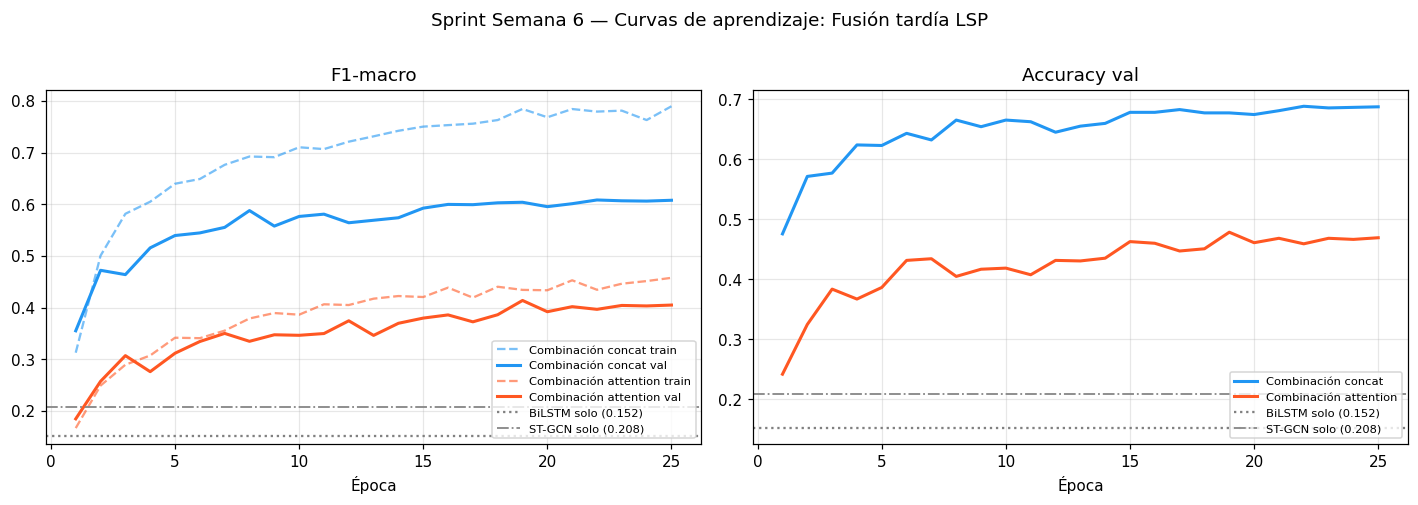

Guardado: data/semana6_curves.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Sprint Semana 6 — Curvas de aprendizaje: Fusión tardía LSP', fontsize=12, y=1.01)

colors = {'Combinación concat': '#2196F3', 'Combinación attention': '#FF5722'}

for name, col in colors.items():
    if name not in results: continue
    h = results[name]['hist']
    ep = range(1, len(h['vl_f1'])+1)
    axes[0].plot(ep, h['tr_f1'], '--', color=col, alpha=0.6, label=f'{name} train')
    axes[0].plot(ep, h['vl_f1'], '-',  color=col, lw=2, label=f'{name} val')
    axes[1].plot(ep, h['vl_acc'], '-', color=col, lw=2, label=name)

# Referencias horizontales
for ax in axes:
    ax.axhline(results['BiLSTM (baseline)']['f1'], color='gray', ls=':',
               lw=1.5, label=f'BiLSTM solo ({results["BiLSTM (baseline)"]["f1"]:.3f})')
    ax.axhline(results['ST-GCN (baseline)']['f1'], color='#888', ls='-.',
               lw=1.2, label=f'ST-GCN solo ({results["ST-GCN (baseline)"]["f1"]:.3f})')

axes[0].set_title('F1-macro'); axes[0].set_xlabel('Época')
axes[1].set_title('Accuracy val'); axes[1].set_xlabel('Época')
for ax in axes:
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(DATA_DIR / 'semana6_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Guardado: data/semana6_curves.png')

## 8. Reporte por clase — mejor variante

In [34]:
best_name = max(
    (k for k in results if 'baseline' not in k),
    key=lambda k: results[k]['f1']
)
best = results[best_name]
print(f'Mejor variante Semana 6: {best_name}  F1-macro={best["f1"]:.4f}')
print('='*60)
print(classification_report(best['y_true'], best['y_pred'],
                             target_names=CLASS_NAMES, zero_division=0, digits=3))

Mejor variante Semana 6: Combinación concat  F1-macro=0.5056
              precision    recall  f1-score   support

  vineta_002      0.574     0.871     0.692        31
  vineta_003      0.982     0.965     0.973       171
  vineta_004      0.324     0.306     0.314        36
  vineta_005      0.435     0.513     0.471        39
  vineta_006      0.717     0.729     0.723        59
  vineta_008      0.600     0.600     0.600        35
  vineta_011      0.071     0.056     0.062        18
  vineta_012      0.611     0.367     0.458        30
  vineta_013      0.250     0.500     0.333        26
  vineta_014      0.562     0.346     0.429        26
  vineta_015      0.608     0.608     0.608        51
  vineta_017      0.766     0.766     0.766        47
  vineta_018      0.643     0.450     0.529        40
  vineta_019      0.450     0.429     0.439        21
  vineta_020      0.176     0.250     0.207        24
  vineta_021      0.619     0.491     0.547        53
  vineta_022      0.

## 9. Guardar checkpoints y log final

In [35]:
import datetime

CKPT_DIR = ROOT / 'checkpoints'
LOG_DIR  = ROOT / 'logs'

log = []
log.append('=' * 65)
log.append('SPRINT SEMANA 6 — RESULTADOS FUSIÓN TARDÍA LSP')
log.append(f'Fecha: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}')
log.append('=' * 65)
log.append('')
log.append(f'{"Modelo":<32} {"Acc":>7} {"F1-macro":>9} {"F1-w":>7}')
log.append('-' * 60)
for name, r in sorted(results.items(), key=lambda x: -x[1]['f1']):
    log.append(f'{name:<32} {r["acc"]:>7.4f} {r["f1"]:>9.4f} {r["f1w"]:>7.4f}')

log_txt = '\n'.join(log)
print(log_txt)
(LOG_DIR / 'semana6_resultados_finales.txt').write_text(log_txt)

# Guardar cabezas de fusión
for name in ['Combinación concat', 'Combinación attention']:
    if name not in results: continue
    slug = name.replace(' ', '_').replace('ó','o').lower()
    ckpt_path = CKPT_DIR / f'semana6_{slug}_best.pt'
    torch.save({
        'head_state':    results[name]['model'].head.state_dict(),
        'strategy':      name.split()[-1].lower(),
        'dim_a':         DIM_A, 'dim_b': DIM_B,
        'n_classes':     N_CLASSES,
        'test_f1_macro': results[name]['f1'],
        'test_acc':      results[name]['acc'],
        'val_f1_best':   results[name]['best_val_f1'],
    }, ckpt_path)
    print(f'Checkpoint: {ckpt_path}')

SPRINT SEMANA 6 — RESULTADOS FUSIÓN TARDÍA LSP
Fecha: 2026-05-22 17:37

Modelo                               Acc  F1-macro    F1-w
------------------------------------------------------------
Combinación concat                0.5905    0.5056  0.5932
Combinación attention             0.3767    0.3197  0.3740
ST-GCN (baseline)                 0.3085    0.2077  0.2833
BiLSTM (baseline)                 0.2684    0.1515  0.2385
Checkpoint: /Users/usuario/Documents/TRADUCTOR_LSP/checkpoints/semana6_combinacion_concat_best.pt
Checkpoint: /Users/usuario/Documents/TRADUCTOR_LSP/checkpoints/semana6_combinacion_attention_best.pt
